# GA Image Approximation — Experiment with init by image

Run cells top to bottom. All src/ modules are added to the path in cell 1.

In [11]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from PIL import Image

import logging
logging.basicConfig(level=logging.INFO, format='%(message)s')

from fitness import build_fitness
from utils import load_target_pil, side_by_side, render, triangles_to_json, save_render
from ga import GeneticAlgorithm, GAConfig, EarlyStopping

from ga_operators.selection import TournamentSelection, RankSelection, RouletteSelection
from ga_operators.crossover import SinglePointCrossover, UniformCrossover, KPointCrossover
from ga_operators.mutation import GaussianMutation, ResetMutation, SwapMutation, CompositeMutation

TARGET_PATH = '../data/Girl_Pearl_Earing.png'
OUTPUT_DIR  = '../outputs3'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('imports ok')

imports ok


## 1. Load and inspect target image

size (W x H) : (300, 400)
array shape  : (400, 300, 3), dtype: uint8


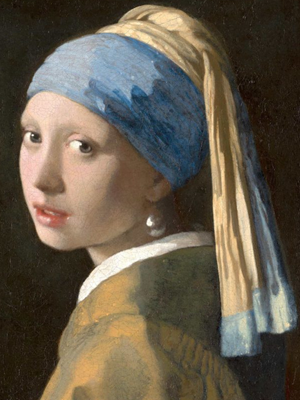

In [12]:
target_pil   = load_target_pil(TARGET_PATH)
target_array = np.array(target_pil)   # H x W x 3, uint8

print(f'size (W x H) : {target_pil.size}')
print(f'array shape  : {target_array.shape}, dtype: {target_array.dtype}')
display(target_pil)

## 2. Build fitness function

Swap `'rmse'` for `'ssim'` or `'ciede2000'` to use a different metric.

In [13]:
FITNESS_METRIC = 'rmse'   # options: 'rmse', 'ssim', 'ciede2000'

fitness_fn = build_fitness(FITNESS_METRIC, target_pil)
print(fitness_fn)

RMSEFitness(target_shape=(400, 300, 3))


## 3. Configure GA

In [14]:
config = GAConfig(
    population_size     = 50,
    n_generations       = 1000,
    crossover_rate      = 0.8,
    n_elites            = 1,
    n_workers           = 1,
    early_stopping      = EarlyStopping(patience=50, tolerance=1e-4),
    checkpoint_interval = 50,
    checkpoint_dir      = f'{OUTPUT_DIR}/checkpoints',
    seed                = 42,
)

mutation = CompositeMutation([
    GaussianMutation(mutation_rate=0.05, vertex_sigma=15.0, color_sigma=15.0),
    ResetMutation(mutation_rate=0.01),
    SwapMutation(mutation_rate=0.2, n_swaps=1),
])

ga = GeneticAlgorithm(
    fitness_fn = fitness_fn,
    selection  = TournamentSelection(tournament_size=5),
    crossover  = SinglePointCrossover(),
    mutation   = mutation,
    config     = config,
)

print(ga)

GeneticAlgorithm(
  selection=TournamentSelection(tournament_size=5),
  crossover=SinglePointCrossover(),
  mutation=CompositeMutation([GaussianMutation(rate=0.05, v_sigma=15.0, c_sigma=15.0), ResetMutation(rate=0.01), SwapMutation(rate=0.2, n_swaps=1)]),
  config=GAConfig(population_size=50, n_generations=1000, crossover_rate=0.8, n_elites=1, n_workers=1, early_stopping=EarlyStopping(patience=50, tolerance=0.0001), checkpoint_interval=50, checkpoint_dir='../outputs3/checkpoints', seed=42)
)


## 4. Run GA

Three initialisation strategies:

- `'random'` -- fully random vertices and colors (baseline)
- `'image'`  -- random vertices, colors sampled from target image at centroid
- `'mixed'`  -- `image_ratio` fraction image-seeded, rest fully random

`target_array` must be passed for `'image'` and `'mixed'`.

In [15]:
INIT_STRATEGY = 'image'   # options: 'random', 'image', 'mixed'
IMAGE_RATIO   = 0.5       # only used when INIT_STRATEGY == 'mixed'

best = ga.run(
    target        = target_array,
    init_strategy = INIT_STRATEGY,
    image_ratio   = IMAGE_RATIO,
)

print(f'best fitness: {best.fitness:.4f}')

Initialising population (size=50, strategy=image).
Checkpoint saved -> ../outputs3/checkpoints/best_gen_00000.json
gen    1 | best=56.0313 | mean=60.7539 | std=2.4610 | div=0.1726 | 1.0s
gen    2 | best=52.5551 | mean=58.2726 | std=2.1319 | div=0.2014 | 1.4s
gen    3 | best=52.3394 | mean=56.2212 | std=1.7636 | div=0.2095 | 1.8s
gen    4 | best=51.5352 | mean=54.3087 | std=1.9459 | div=0.1954 | 2.2s
gen    5 | best=50.7688 | mean=53.0721 | std=1.2750 | div=0.2184 | 2.7s
gen    6 | best=50.5518 | mean=52.2766 | std=1.1171 | div=0.2122 | 3.1s
gen    7 | best=49.9610 | mean=51.5288 | std=0.8893 | div=0.1738 | 3.5s
gen    8 | best=49.8936 | mean=51.2691 | std=1.3933 | div=0.1635 | 3.9s
gen    9 | best=49.2360 | mean=51.0648 | std=1.8784 | div=0.1509 | 4.3s
gen   10 | best=48.4935 | mean=50.3424 | std=1.0519 | div=0.1926 | 4.7s
gen   11 | best=48.2374 | mean=50.0710 | std=1.2927 | div=0.1900 | 5.1s
gen   12 | best=47.6476 | mean=49.5337 | std=1.1490 | div=0.1802 | 5.6s
gen   13 | best=47.64

best fitness: 34.0123


## 5. Save results

In [16]:
ga.save_log(f'{OUTPUT_DIR}/run_log.json')
ga.save_config(f'{OUTPUT_DIR}/run_config.json')
triangles_to_json(list(best.triangles), f'{OUTPUT_DIR}/best_individual.json')
save_render(render(best.triangles), f'{OUTPUT_DIR}/best_render.png')

print('results saved to', OUTPUT_DIR)

Generation log saved -> ../outputs3/run_log.json
Run config saved -> ../outputs3/run_config.json


results saved to ../outputs3


## 6. Convergence plot

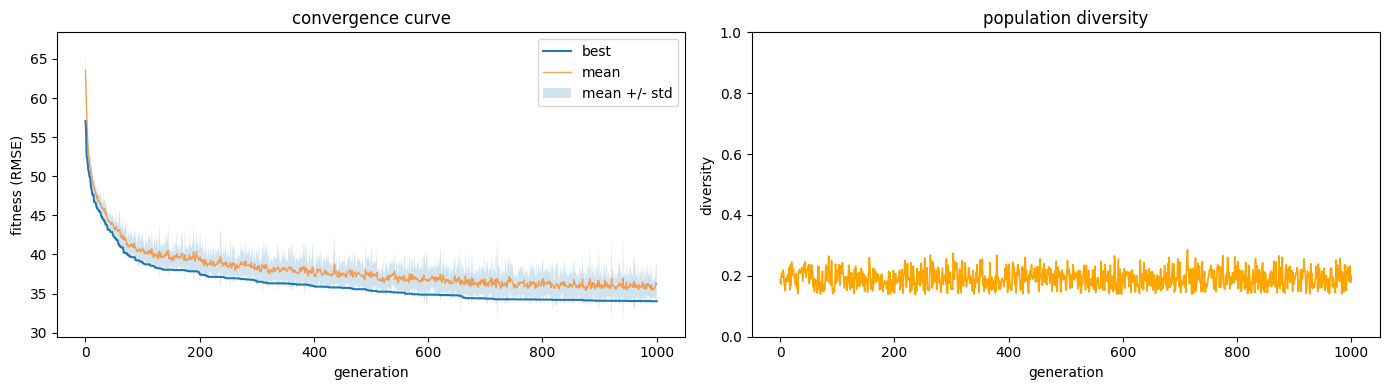

final best  : 34.0123
generations : 1001
elapsed     : 485.2s


In [17]:
log_df = pd.DataFrame(ga.generation_log)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# left: fitness over generations
ax = axes[0]
ax.plot(log_df['generation'], log_df['best'], label='best', linewidth=1.5)
ax.plot(log_df['generation'], log_df['mean'], label='mean', linewidth=1.0, alpha=0.7)
ax.fill_between(
    log_df['generation'],
    log_df['mean'] - log_df['std'],
    log_df['mean'] + log_df['std'],
    alpha=0.2, label='mean +/- std'
)
ax.set_xlabel('generation')
ax.set_ylabel(f'fitness ({FITNESS_METRIC.upper()})')
ax.set_title('convergence curve')
ax.legend()

# right: population diversity over generations
ax2 = axes[1]
ax2.plot(log_df['generation'], log_df['diversity'], color='orange', linewidth=1.2)
ax2.set_xlabel('generation')
ax2.set_ylabel('diversity')
ax2.set_title('population diversity')
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/convergence.png', dpi=150)
plt.show()

print(f'final best  : {log_df["best"].iloc[-1]:.4f}')
print(f'generations : {len(log_df)}')
print(f'elapsed     : {log_df["elapsed_s"].iloc[-1]:.1f}s')

## 7. Visual comparison — target vs best

target -- left   |   best GA -- right


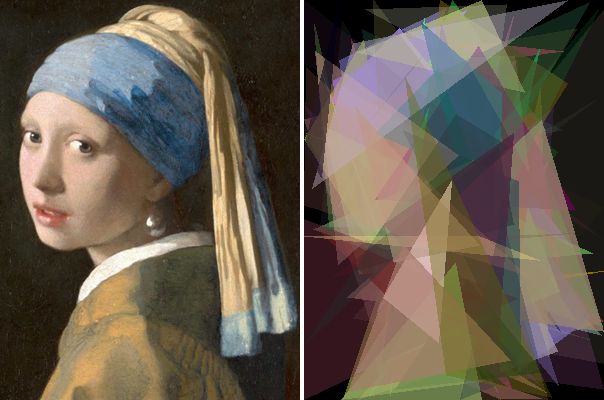

In [18]:
best_arr   = render(best.triangles)
comparison = side_by_side(target_array, best_arr)

print('target -- left   |   best GA -- right')
display(comparison)
comparison.save(f'{OUTPUT_DIR}/comparison.png')

## 8. Checkpoint inspection (optional)

Load and display saved checkpoints to see how the image evolved over generations.

found 21 checkpoints
generation 00000


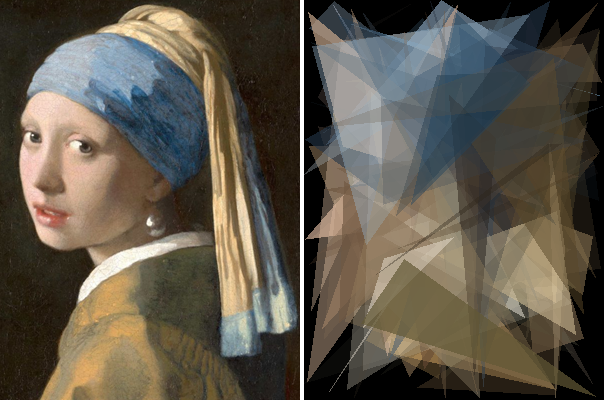

generation 00200


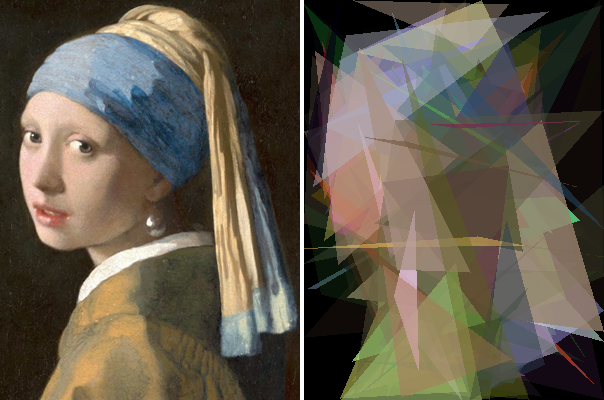

generation 00400


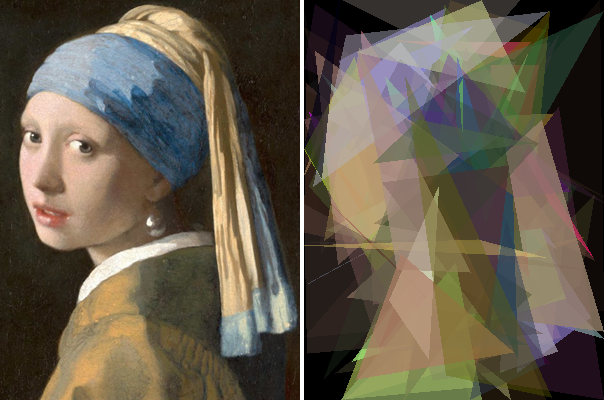

generation 00600


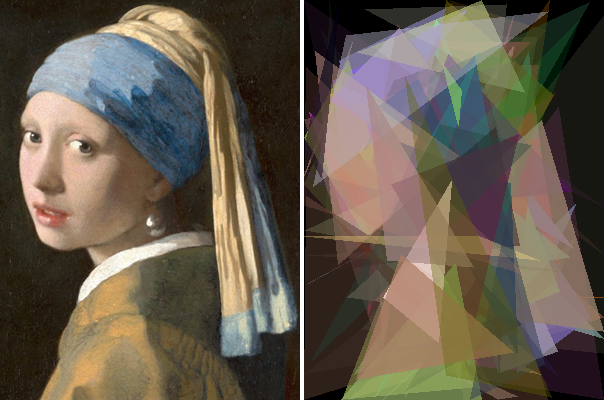

generation 00800


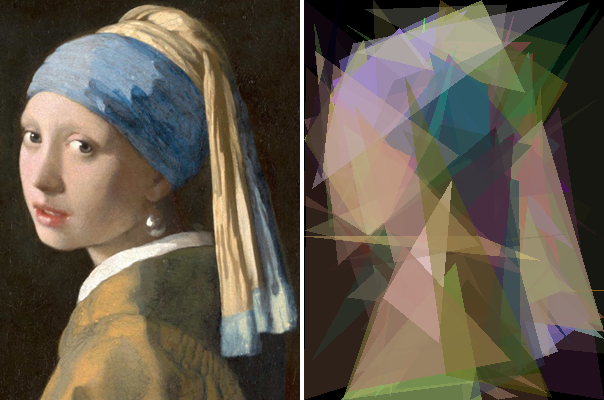

generation 01000


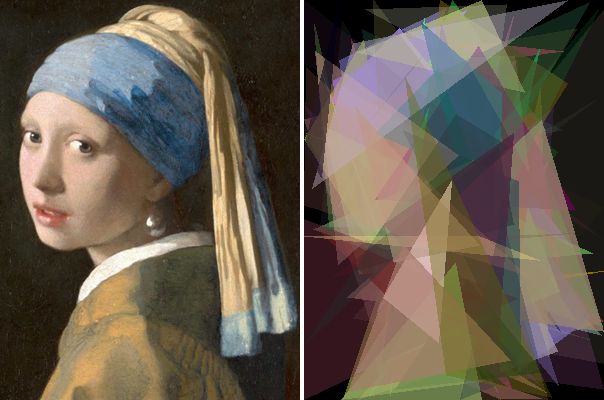

In [19]:
from utils import triangles_from_json

checkpoint_dir = f'{OUTPUT_DIR}/checkpoints'
checkpoints = sorted([
    f for f in os.listdir(checkpoint_dir) if f.endswith('.json')
])

print(f'found {len(checkpoints)} checkpoints')

# display every Nth checkpoint to keep output manageable
N = max(1, len(checkpoints) // 5)

for fname in checkpoints[::N]:
    gen_label = fname.replace('best_gen_', '').replace('.json', '')
    tris = triangles_from_json(os.path.join(checkpoint_dir, fname))
    arr  = render(tris)
    comp = side_by_side(target_array, arr)
    print(f'generation {gen_label}')
    display(comp)